In [1]:
# ===============================
# 1️⃣ Libraries
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import QuantileTransformer, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Dense, Dropout, Embedding, Concatenate,
    Reshape, LayerNormalization, MultiHeadAttention,
    Add, Flatten
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

In [3]:
# df = pd.read_csv('/content/drive/MyDrive/Book1.csv')
# if 'Block_ID' in df.columns:
#     df = df.drop(columns=['Block_ID'])

In [4]:
# ===============================
# 2️⃣ Load Dataset
# ===============================
df = pd.read_csv("Book1.csv")

if 'Block_ID' in df.columns:
    df = df.drop(columns=['Block_ID'])

In [5]:
# ===============================
# 3️⃣ Split Features and Target
# ===============================
X = df.drop(columns=['Resilience_Score'])
y = df['Resilience_Score']

In [6]:
# ===============================
# 4️⃣ Column Definition
# ===============================
num_cols = [
    "Building_Age_Years", "Number_of_Floors", "Urban_Deterioration_Level",
    "NDVI", "NDBI", "Texture_GLCM", "BuiltUp_Density_Image", "PGA_g",
    "Distance_to_Fault_m", "Distance_to_Hospital_m", "Distance_to_FireStation_m",
    "Parcel_Area_m2", "Road_Width_m", "Road_Density",
    "Emergency_Access_Time_min", "Slope_Percent", "Elevation_m", "FAR",
    "Building_Coverage_Percent"
]

cat_cols = [
    "Building_Skeleton_Type",
    "Building_Material_Type",
    "Soil_Type_Vs30",
    "CulDeSac_YesNo"
]

In [7]:
# ===============================
# 5️⃣ Train Test Split
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
# ===============================
# 6️⃣ Numeric Scaling
# ===============================
scaler = QuantileTransformer(
    n_quantiles=800,
    output_distribution="normal",
    random_state=42
)

X_num_train = scaler.fit_transform(X_train[num_cols])
X_num_test  = scaler.transform(X_test[num_cols])

In [9]:
# ===============================
# 7️⃣ Categorical Encoding
# ===============================
X_cat_train = X_train[cat_cols].copy()
X_cat_test  = X_test[cat_cols].copy()

label_encoders = {}
cat_input_dims = []

for col in cat_cols:
    X_cat_train[col] = X_cat_train[col].astype(str)
    X_cat_test[col]  = X_cat_test[col].astype(str)

    all_values = pd.concat([X_cat_train[col], X_cat_test[col]])
    le = LabelEncoder()
    le.fit(all_values)

    X_cat_train[col] = le.transform(X_cat_train[col])
    X_cat_test[col]  = le.transform(X_cat_test[col])

    label_encoders[col] = le
    cat_input_dims.append(len(le.classes_))

In [10]:
# بررسی داده‌های پیش‌پردازش شده
def inspect_preprocessed_data(X_num_train, X_cat_train, X_num_test, X_cat_test, cat_cols, num_cols):
    print("=== Numeric Features ===")
    print("Train shape:", X_num_train.shape)
    print("Test shape :", X_num_test.shape)
    print("Train stats (mean/std/min/max):")
    print(np.round(np.mean(X_num_train, axis=0),3))
    print(np.round(np.std(X_num_train, axis=0),3))
    print(np.round(np.min(X_num_train, axis=0),3))
    print(np.round(np.max(X_num_train, axis=0),3))

    print("\n=== Categorical Features ===")
    for col in cat_cols:
        print(f"Column: {col}")
        print("  Train unique:", np.unique(X_cat_train[col]))
        print("  Test unique :", np.unique(X_cat_test[col]))

# اجرای تابع
inspect_preprocessed_data(X_num_train, X_cat_train, X_num_test, X_cat_test, cat_cols, num_cols)

=== Numeric Features ===
Train shape: (6400, 19)
Test shape : (1600, 19)
Train stats (mean/std/min/max):
[-0.005  0.018  0.05  -0.    -0.     0.     0.    -0.     0.     0.001
 -0.001  0.01  -0.037  0.    -0.     0.    -0.002  0.     0.014]
[1.526 2.6   4.303 1.002 1.002 1.003 1.002 1.003 1.01  1.006 1.004 1.042
 1.613 1.003 1.002 1.002 1.063 1.002 1.309]
[-5.199 -5.199 -5.199 -5.199 -5.199 -5.199 -5.199 -5.199 -5.199 -5.199
 -5.199 -5.199 -5.199 -5.199 -5.199 -5.199 -5.199 -5.199 -5.199]
[5.199 5.199 5.199 5.199 5.199 5.199 5.199 5.199 5.199 5.199 5.199 5.199
 5.199 5.199 5.199 5.199 5.199 5.199 5.199]

=== Categorical Features ===
Column: Building_Skeleton_Type
  Train unique: [0 1 2 3]
  Test unique : [0 1 2 3]
Column: Building_Material_Type
  Train unique: [0 1 2 3]
  Test unique : [0 1 2 3]
Column: Soil_Type_Vs30
  Train unique: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37

In [11]:
# # ===============================
# # 8️⃣ Transformer Block
# # ===============================
# def transformer_block(x, embed_dim, num_heads, ff_dim, dropout=0.3):
#     attn_output = MultiHeadAttention(
#         num_heads=num_heads,
#         key_dim=embed_dim // num_heads  # ✅ key_dim اصلاح شد
#     )(x, x)
#     attn_output = Dropout(dropout)(attn_output)
#     x = Add()([x, attn_output])
#     x = LayerNormalization()(x)

#     ffn = Dense(ff_dim, activation="relu")(x)
#     ffn = Dense(embed_dim)(ffn)
#     ffn = Dropout(dropout)(ffn)

#     x = Add()([x, ffn])
#     x = LayerNormalization()(x)
#     return x

In [12]:
from tensorflow.keras.layers import *

def build_cnn_lstm(num_numeric, cat_input_dims):

    # =====================
    # NUMERIC INPUT
    # =====================
    num_input = Input(shape=(num_numeric,), name="num_input")

    # تبدیل به sequence
    x = Reshape((num_numeric, 1))(num_input)

    # =====================
    # CNN BLOCK
    # =====================
    x = Conv1D(64, kernel_size=3, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)

    x = Conv1D(128, kernel_size=3, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)

    # =====================
    # LSTM BLOCK
    # =====================
    x = LSTM(128, return_sequences=True)(x)
    x = Dropout(0.2)(x)

    x = LSTM(64, return_sequences=False)(x)

    # =====================
    # CATEGORICAL EMBEDDINGS
    # =====================
    cat_inputs = []
    cat_embeds = []

    for i, card in enumerate(cat_input_dims):
        inp = Input(shape=(1,), name=f"cat_{i}")

        emb_dim = min(16, card // 2 + 1)
        emb = Embedding(input_dim=card, output_dim=emb_dim)(inp)
        emb = Flatten()(emb)

        cat_inputs.append(inp)
        cat_embeds.append(emb)

    # =====================
    # MERGE
    # =====================
    x = Concatenate()([x] + cat_embeds)

    # =====================
    # DENSE HEAD
    # =====================
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)

    x = Dense(64, activation='relu')(x)

    output = Dense(1)(x)

    model = Model(inputs=[num_input] + cat_inputs, outputs=output)

    return model

In [13]:
# # ===============================
# # 🔟 Compile Model
# # ===============================
# model = build_ft_transformer(
#     X_num_train.shape[1],
#     cat_input_dims
# )

# model.compile(
#     optimizer=Adam(learning_rate=0.0005),
#     loss="mse"
# )

# model.summary()

In [14]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Embedding, Dropout, Flatten, Add, LayerNormalization,
    Concatenate, Lambda, MultiHeadAttention
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow as tf

In [15]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

es = EarlyStopping(monitor="val_loss", patience=8, min_delta=1e-4, restore_best_weights=True)
rlrop = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6)

model = build_cnn_lstm(num_numeric=len(num_cols),
                             cat_input_dims=cat_input_dims)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
              loss="mse")  # Regression

history = model.fit(
    [X_num_train] + [X_cat_train[col] for col in cat_cols],
    y_train,
    validation_data=([X_num_test] + [X_cat_test[col] for col in cat_cols], y_test),
    epochs=100,
    batch_size=16,
    callbacks=[es, rlrop],
    verbose=1
)

Epoch 1/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 17s 31ms/step - loss: 0.0583 - val_loss: 0.0516 - learning_rate: 5.0000e-04
Epoch 2/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 19s 28ms/step - loss: 0.0427 - val_loss: 0.0454 - learning_rate: 5.0000e-04
Epoch 3/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - loss: 0.0383 - val_loss: 0.0467 - learning_rate: 5.0000e-04
Epoch 4/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - loss: 0.0372 - val_loss: 0.0428 - learning_rate: 5.0000e-04
Epoch 5/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - loss: 0.0347 - val_loss: 0.0415 - learning_rate: 5.0000e-04
Epoch 6/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - loss: 0.0313 - val_loss: 0.0378 - learning_rate: 5.0000e-04
Epoch 7/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 21s 28ms/step - loss: 0.0272 - val_loss: 0.0317 - learning_rate: 5.0000e-04
Epoch 8/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - loss: 0.0237 - val_loss: 0.0275 - learning_rate: 5.0000e-04
Epoch 9/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - loss: 0

In [16]:
# ===============================
# 1️⃣2️⃣ Evaluation
# ===============================
y_pred = model.predict(
    [X_num_test] + [X_cat_test[col] for col in cat_cols],
    verbose=0
)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("CNN-LSTM RMSE:", rmse)
print("CNN-LSTM R2  :", r2)

CNN-LSTM RMSE: 0.09749785463381819
CNN-LSTM R2  : 0.8321264730334325


از اینجا میشه طبقه بندی

In [17]:
# ===============================
# 1️⃣2️⃣ Evaluation (FULL)
# ===============================
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Predict
y_pred = model.predict(
    [X_num_test] + [X_cat_test[col] for col in cat_cols],
    verbose=0
)

# --- Regression Metrics ---
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

# Adjusted R2
n = len(y_test)
p = X_num_test.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("RMSE :", rmse)
print("MAE  :", mae)
print("R2   :", r2)
print("AdjR2:", adj_r2)

RMSE : 0.09749785463381819
MAE  : 0.041192620201686625
R2   : 0.8321264730334325
AdjR2: 0.8301077407471256


In [18]:
# تبدیل به کلاس (مثلاً binary)
y_class = (y > 0.5).astype(int)

# split
X_train, X_test, y_train, y_test, y_train_class, y_test_class = train_test_split(
    X, y, y_class, test_size=0.2, random_state=42
)

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# خروجی مدل (Regression)
y_pred = model.predict(
    [X_num_test] + [X_cat_test[col] for col in cat_cols],
    verbose=0
).flatten()

# تبدیل به کلاس
y_pred_class = (y_pred > 0.5).astype(int)

# Metrics
accuracy  = accuracy_score(y_test_class, y_pred_class)
precision = precision_score(y_test_class, y_pred_class)
recall    = recall_score(y_test_class, y_pred_class)
f1        = f1_score(y_test_class, y_pred_class)

roc_auc = roc_auc_score(y_test_class, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)
print("ROC-AUC  :", roc_auc)

Accuracy : 0.933125
Precision: 0.9399538106235565
Recall   : 0.9367088607594937
F1-score : 0.938328530259366
ROC-AUC  : 0.9653831077751839


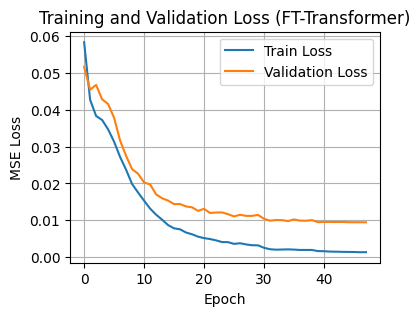

In [20]:
plt.figure(figsize=(4,3))
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training and Validation Loss (FT-Transformer)")
plt.legend()
plt.grid(True)
plt.show()

In [21]:
# ===============================
# 🔥 1️⃣ Convert to GeoDataFrame
# ===============================
import geopandas as gpd
from shapely.geometry import Point

df_full = pd.read_csv("Book1.csv")

geometry = [Point(xy) for xy in zip(df_full["X_Coord"], df_full["Y_Coord"])]
gdf = gpd.GeoDataFrame(df_full, geometry=geometry)

In [22]:
# اضافه کردن پیش‌بینی به دیتا
gdf = gdf.loc[X_test.index]   # هماهنگ با تست دیتا
gdf['Predicted_Resilience'] = y_pred.flatten()

In [23]:
from libpysal.weights import KNN
from esda.moran import Moran
import numpy as np

coords = np.array(list(zip(gdf.geometry.x, gdf.geometry.y)))
w = KNN.from_array(coords, k=8)
w.transform = 'r'

y_spatial = gdf['Resilience_Score']

mi = Moran(y_spatial, w)

print("Moran’s I:", mi.I)

Moran’s I: 0.1140803897335752


In [24]:
from esda.moran import Moran_Local

lisa = Moran_Local(y_spatial, w)

gdf['LISA_cluster'] = lisa.q

In [25]:
from esda.getisord import G_Local

g = G_Local(y_spatial, w)

gdf['GiZ'] = g.Zs

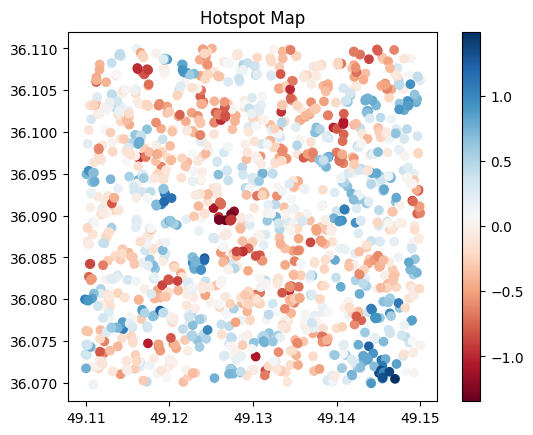

In [26]:
import matplotlib.pyplot as plt

gdf.plot(column='GiZ', cmap='RdBu', legend=True)
plt.title("Hotspot Map")
plt.show()

Text(0, 0.5, 'Predicted')

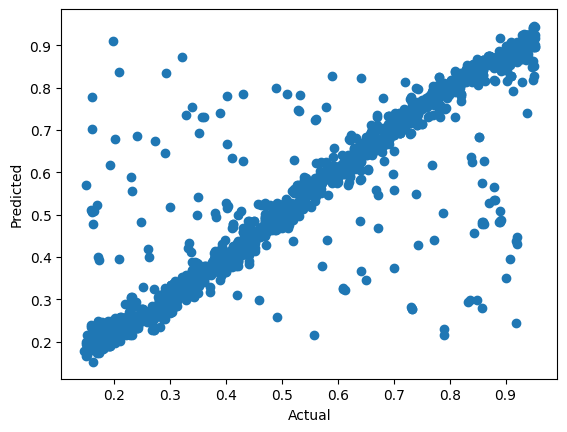

In [27]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")

In [28]:
y_pred = model.predict([X_num_test] + [X_cat_test[col] for col in cat_cols])

gdf_test = X_test.copy()
gdf_test['Resilience'] = y_pred

50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


In [29]:
gdf_test['Vulnerability'] = 1 - gdf_test['Resilience']

In [30]:
gdf_test['Risk'] = gdf_test['PGA_g'] * gdf_test['Vulnerability']

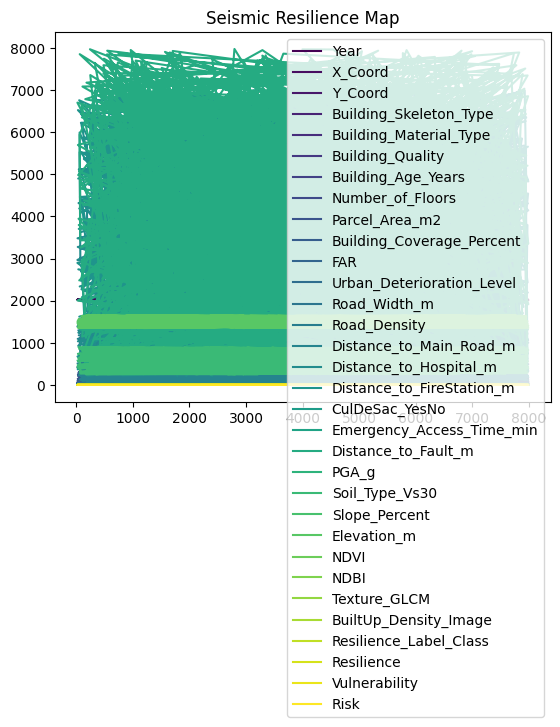

In [31]:
gdf_test.plot(column='Resilience', cmap='viridis', legend=True)
plt.title("Seismic Resilience Map")
plt.show()

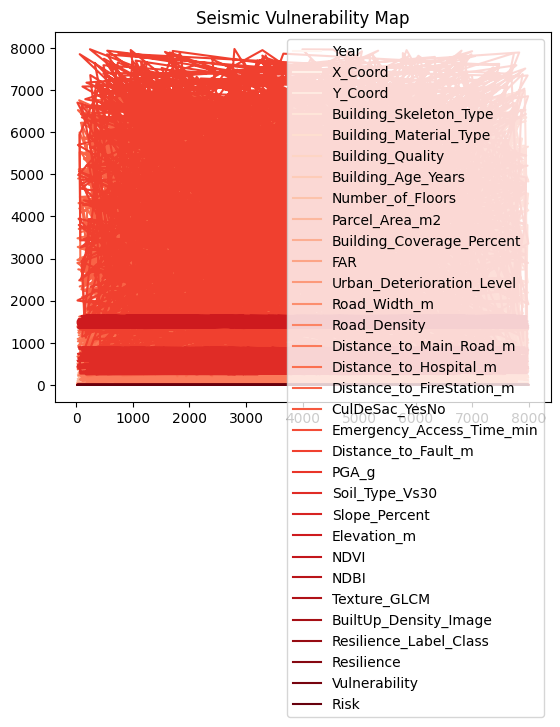

In [32]:
gdf_test.plot(column='Vulnerability', cmap='Reds', legend=True)
plt.title("Seismic Vulnerability Map")
plt.show()

In [33]:
gdf['Resilience'] = y_pred

In [34]:
gdf['Resilience'] = gdf['Resilience_Score']

In [35]:
gdf['Vulnerability'] = 1 - gdf['Resilience']

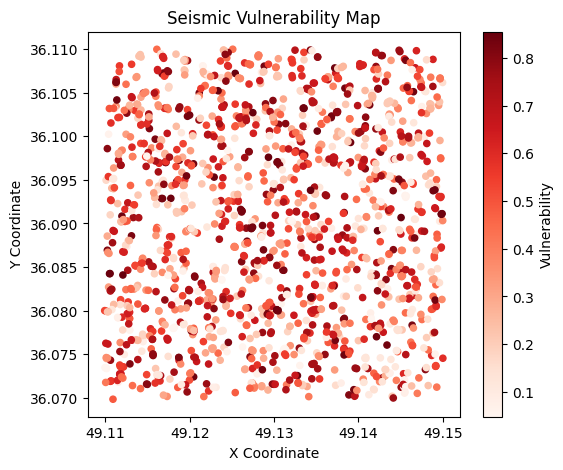

In [36]:
plt.figure(figsize=(6,5))

plt.scatter(
    gdf['X_Coord'],
    gdf['Y_Coord'],
    c=gdf['Vulnerability'],
    cmap='Reds',
    s=20
)

plt.colorbar(label='Vulnerability')
plt.title("Seismic Vulnerability Map")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.show()

<Axes: >

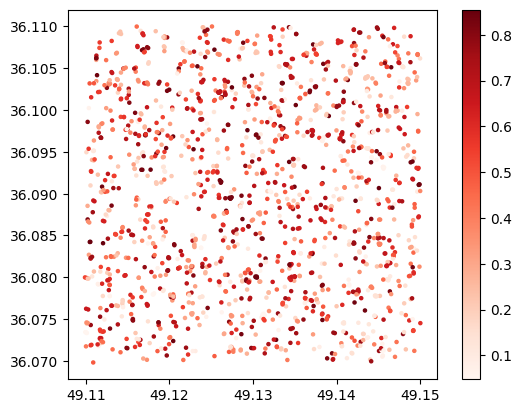

In [37]:
gdf.plot(
    column='Vulnerability',
    cmap='Reds',
    legend=True,
    markersize=5
)

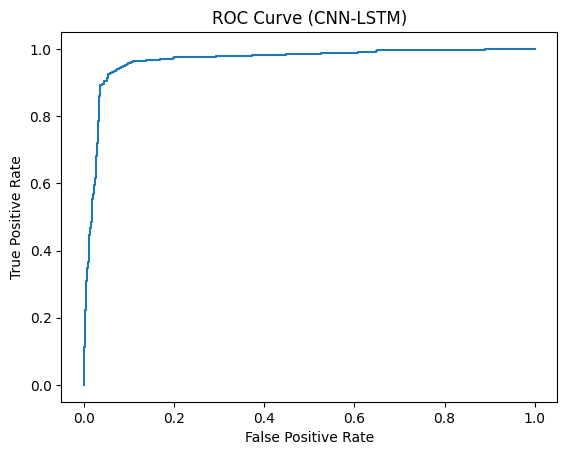

In [38]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# اگر قبلاً ساختی:
# y_pred = model.predict(...).flatten()

threshold = 0.5
y_pred_class = (y_pred > threshold).astype(int)
y_test_class = (y_test > threshold).astype(int)

# ROC
fpr, tpr, _ = roc_curve(y_test_class, y_pred)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (CNN-LSTM)")
plt.show()

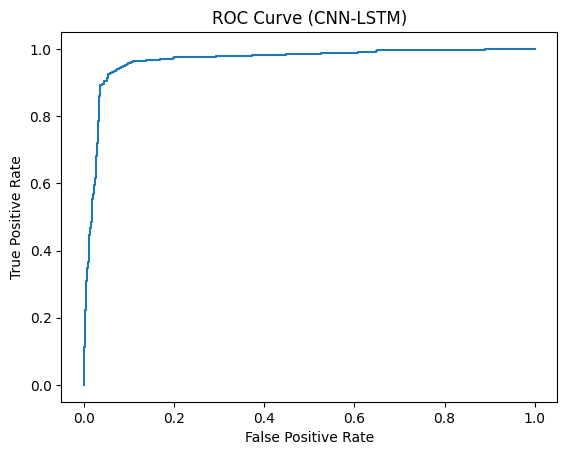

In [39]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# اگر قبلاً ساختی:
# y_pred = model.predict(...).flatten()

threshold = 0.5
y_pred_class = (y_pred > threshold).astype(int)
y_test_class = (y_test > threshold).astype(int)

# ROC
fpr, tpr, _ = roc_curve(y_test_class, y_pred)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (CNN-LSTM)")
plt.show()

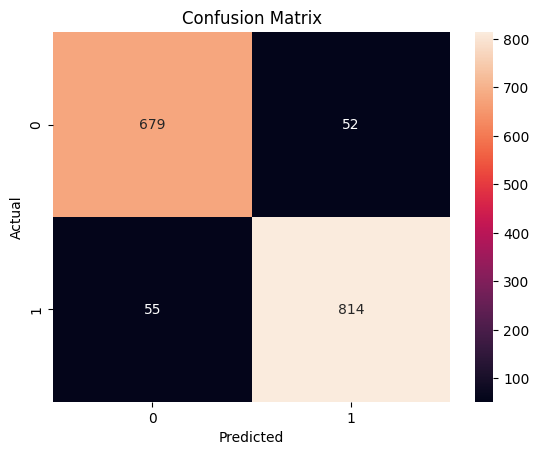

In [40]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test_class, y_pred_class)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

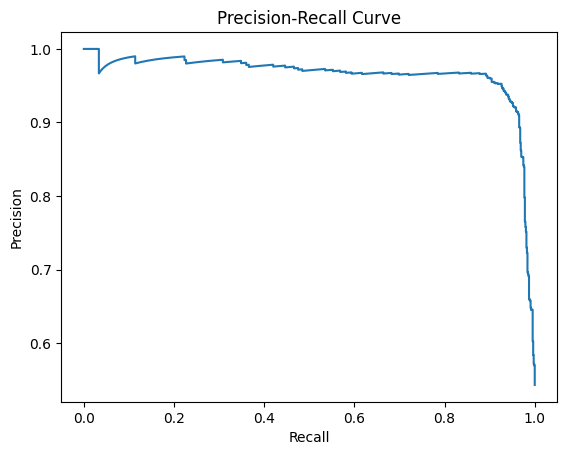

In [41]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test_class, y_pred)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()